In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec

import yfinance as yf

from scipy.stats import chi2, kurtosis, norm, skew, t

import statsmodels.api as sm
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.diagnostic import acorr_ljungbox

from arch import arch_model

from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import het_arch

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

In [ ]:
tickers = ['RELIANCE.NS', 'INFY.NS', 'HDFCBANK.NS', 'ITC.NS', 'TMPV.NS']
weights = np.array([0.2, 0.2, 0.2, 0.2, 0.2])

start_date = '2021-07-31'
end_date = '2026-07-31'
data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)['Close']

print("Missing values per stock:", data.isnull().sum())

data = data.ffill().dropna()

returns = np.log(data / data.shift(1)).dropna()

portfolio_returns = (returns * weights).sum(axis=1)

returns.to_csv('stock_returns.csv')
portfolio_returns.to_csv('portfolio_returns.csv')

$ITC.NS: possibly delisted; no price data found  (1d 2021-07-31 -> 2026-07-31)
[*******************   40%                       ]  2 of 5 completed$RELIANCE.NS: possibly delisted; no price data found  (1d 2021-07-31 -> 2026-07-31)
[**********************60%****                   ]  3 of 5 completed$HDFCBANK.NS: possibly delisted; no price data found  (1d 2021-07-31 -> 2026-07-31)
[**********************80%*************          ]  4 of 5 completed

In [ ]:
print(portfolio_returns.describe() * 100)
print(portfolio_returns.head())
print(portfolio_returns.tail())

count    123700.000000
mean          0.015193
std           1.049257
min         -10.418221
25%          -0.508994
50%           0.041315
75%           0.617886
max           4.970880
dtype: float64
Date
2021-08-03    0.013087
2021-08-04    0.000096
2021-08-05    0.013364
2021-08-06   -0.004337
2021-08-09    0.000216
dtype: float64
Date
2026-07-24   -0.000316
2026-07-27    0.010713
2026-07-28   -0.001040
2026-07-29    0.017992
2026-07-30    0.005902
dtype: float64


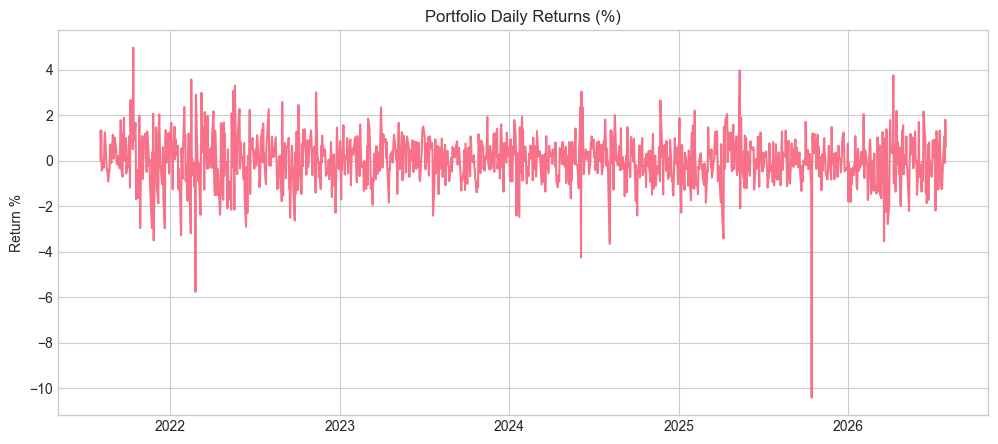

In [ ]:
ret_pct = portfolio_returns * 100

plt.figure(figsize=(12, 5))
plt.plot(ret_pct.index, ret_pct)
plt.title('Portfolio Daily Returns (%)')
plt.ylabel('Return %')
plt.grid(True)
plt.show()

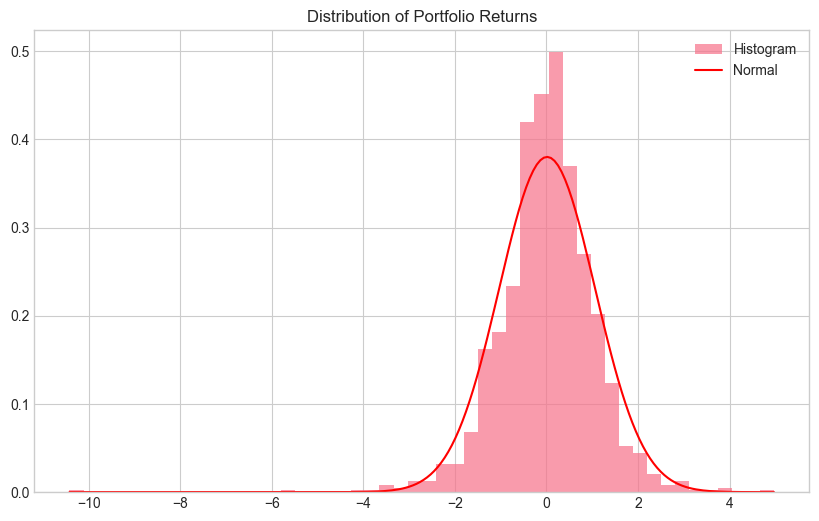

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ret_pct.hist(bins=50, density=True, alpha=0.7, label='Histogram')
x = np.linspace(ret_pct.min(), ret_pct.max(), 200)
ax.plot(x, norm.pdf(x, ret_pct.mean(), ret_pct.std()), 'r-', label='Normal')
ax.set_title('Distribution of Portfolio Returns')
ax.legend()
plt.show()

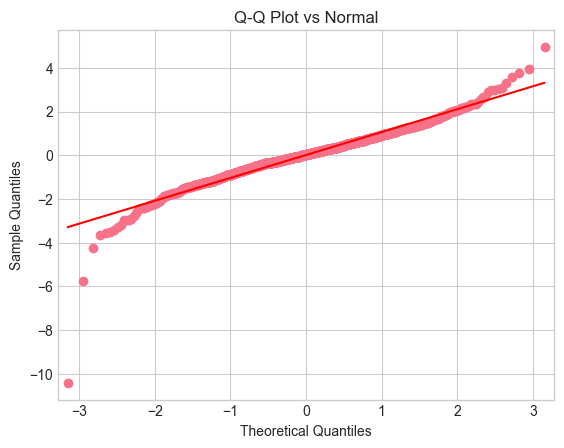

In [ ]:
sm.qqplot(ret_pct, line='s')
plt.title('Q-Q Plot vs Normal')
plt.show()

In [ ]:
kpss_stat, p_value, _, _ = sm.tsa.kpss(ret_pct, regression='c', nlags='auto')
print(f"KPSS test p-value: {p_value:.4f}")

lb_returns = acorr_ljungbox(ret_pct, lags=20, return_df=True)
print("Ljung-Box p-values for returns (first 5 lags):")
print(lb_returns['lb_pvalue'].head())

lb_sq = acorr_ljungbox(ret_pct**2, lags=20, return_df=True)
print("Ljung-Box p-values for squared returns (first 5 lags):")
print(lb_sq['lb_pvalue'].head())

print(f"Skewness: {skew(ret_pct):.4f}")
print(f"Excess Kurtosis: {kurtosis(ret_pct, fisher=True):.4f}")

KPSS test p-value: 0.0237
Ljung-Box p-values for returns (first 5 lags):
1    0.694789
2    0.703074
3    0.685952
4    0.676261
5    0.569397
Name: lb_pvalue, dtype: float64
Ljung-Box p-values for squared returns (first 5 lags):
1    0.122388
2    0.240402
3    0.372633
4    0.460648
5    0.604814
Name: lb_pvalue, dtype: float64
Skewness: -0.9366
Excess Kurtosis: 9.4696


In [ ]:
ret = pd.read_csv('portfolio_returns.csv', index_col=0, parse_dates=True).squeeze()

ret_scaled = ret * 100

print("Original mean daily return: {:.6f}%".format(ret.mean() * 100))
print("Scaled mean daily return: {:.6f}%".format(ret_scaled.mean()))

Original mean daily return: 0.015193%
Scaled mean daily return: 0.015193%


In [ ]:
jb_stat, jb_p = jarque_bera(ret_pct)
print(f"Jarque-Bera p-value: {jb_p:.4f}")

Jarque-Bera p-value: 0.0000


In [ ]:
egarch_t = arch_model(ret_scaled, mean='Constant', vol='EGARCH', p=0, o=1, q=1, dist='StudentsT')
res_egarch = egarch_t.fit(disp='off')

print(res_egarch.summary())

                        Constant Mean - EGARCH Model Results                        
Dep. Variable:                            0   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                           EGARCH   Log-Likelihood:               -1719.35
Distribution:      Standardized Student's t   AIC:                           3448.70
Method:                  Maximum Likelihood   BIC:                           3474.30
                                              No. Observations:                 1237
Date:                      Fri, Jul 31 2026   Df Residuals:                     1236
Time:                              21:29:04   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
m

In [ ]:
garch_t = arch_model(ret_scaled, mean='Constant', p=1, q=1, dist='StudentsT')
res_garch = garch_t.fit(disp='off')

print(res_garch.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                            0   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -1707.72
Distribution:      Standardized Student's t   AIC:                           3425.45
Method:                  Maximum Likelihood   BIC:                           3451.05
                                              No. Observations:                 1237
Date:                      Fri, Jul 31 2026   Df Residuals:                     1236
Time:                              21:29:05   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
m

In [ ]:
print(f"EGARCH AIC: {res_egarch.aic:.2f}, BIC: {res_egarch.bic:.2f}")
print(f"GARCH AIC: {res_garch.aic:.2f}, BIC: {res_garch.bic:.2f}")

EGARCH AIC: 3448.70, BIC: 3474.30
GARCH AIC: 3425.45, BIC: 3451.05


In [ ]:
alpha = res_garch.params['alpha[1]']
beta = res_garch.params['beta[1]']
print(f"GARCH alpha+beta = {alpha+beta:.4f} (should be <1)")

beta_eg = res_egarch.params['beta[1]']
print(f"EGARCH beta = {beta_eg:.4f} (should be <1)")

GARCH alpha+beta = 0.8808 (should be <1)
EGARCH beta = 0.7084 (should be <1)


In [ ]:
print(f"EGARCH nu: {res_egarch.params['nu']:.2f}")
print(f"GARCH nu: {res_garch.params['nu']:.2f}")

EGARCH nu: 4.93
GARCH nu: 5.82


In [ ]:
std_resid_eg = res_egarch.std_resid
std_resid_g = res_garch.std_resid

In [ ]:
lb_eg = acorr_ljungbox(std_resid_eg, lags=10, return_df=True)
lb_g = acorr_ljungbox(std_resid_g, lags=10, return_df=True)
print("\nEGARCH residuals LB p-values (first 5):")
print(lb_eg['lb_pvalue'].head())
print("\nGARCH residuals LB p-values (first 5):")
print(lb_g['lb_pvalue'].head())


EGARCH residuals LB p-values (first 5):
1    0.394378
2    0.346711
3    0.393458
4    0.382576
5    0.374097
Name: lb_pvalue, dtype: float64

GARCH residuals LB p-values (first 5):
1    0.136399
2    0.236671
3    0.380453
4    0.476171
5    0.513045
Name: lb_pvalue, dtype: float64


In [ ]:
lb_eg_sq = acorr_ljungbox(std_resid_eg**2, lags=10, return_df=True)
lb_g_sq = acorr_ljungbox(std_resid_g**2, lags=10, return_df=True)
print("\nEGARCH squared residuals LB p-values (first 5):")
print(lb_eg_sq['lb_pvalue'].head())
print("\nGARCH squared residuals LB p-values (first 5):")
print(lb_g_sq['lb_pvalue'].head())


EGARCH squared residuals LB p-values (first 5):
1    0.140150
2    0.137200
3    0.106258
4    0.147509
5    0.236570
Name: lb_pvalue, dtype: float64

GARCH squared residuals LB p-values (first 5):
1    0.836296
2    0.861293
3    0.922615
4    0.969530
5    0.968986
Name: lb_pvalue, dtype: float64


In [ ]:
arch_test = het_arch(std_resid_g)
print(f"ARCH LM p-value: {arch_test[1]:.4f}")

ARCH LM p-value: 0.9887


In [ ]:
def expected_shortfall_t(mu, sigma, nu, alpha=0.025):
    q = t.ppf(alpha, nu)
    f_q = t.pdf(q, nu)
    es_factor = (f_q / alpha) * ((nu + q**2) / (nu - 1))
    es = mu - sigma * es_factor  # Negative: loss magnitude
    return es

Number of forecast days: 237

First 5 forecast records:
              actual        mu     sigma        nu    var_99    es_975
date                                                                  
2025-08-19  1.323749  0.074577  0.809405  6.776019 -2.374504 -2.450151
2025-08-20  0.180131  0.074246  0.896469  6.748083 -2.641525 -2.725843
2025-08-21  0.052335  0.074709  0.856636  6.760699 -2.518984 -2.599325
2025-08-22 -1.118622  0.072535  0.823985  6.682888 -2.430755 -2.509423
2025-08-25  0.876797  0.071890  0.896273  6.716983 -2.646950 -2.731850

Last 5 forecast records:
              actual        mu     sigma        nu    var_99    es_975
date                                                                  
2026-07-24 -0.031566  0.027038  0.955494  6.200472 -2.943530 -3.046261
2026-07-27  1.071288  0.025950  0.892080  6.167804 -2.752204 -2.848945
2026-07-28 -0.104002  0.027651  0.921711  6.213634 -2.835938 -2.934696
2026-07-29  1.799175  0.028712  0.872089  6.156774 -2.688763 -2.78

In [ ]:
ret = pd.read_csv('portfolio_returns.csv', index_col=0, parse_dates=True).squeeze()
ret_scaled = ret * 100

window = 1000
forecasts = []

for i in range(window, len(ret_scaled)):
    data = ret_scaled.iloc[i-window:i]
    try:
        model = arch_model(data, mean='Constant', p=1, q=1, dist='StudentsT')
        res = model.fit(disp='off')
        
        mu = res.params['mu']
        var_fore = res.forecast(horizon=1).variance.iloc[-1, 0]
        sigma = np.sqrt(var_fore)
        nu = res.params['nu']
        
        var_99 = mu + sigma * t.ppf(0.01, nu)
        es_975 = expected_shortfall_t(mu, sigma, nu, alpha=0.025)
        
        forecasts.append({
            'date': ret_scaled.index[i],
            'actual': ret_scaled.iloc[i],
            'mu': mu,
            'sigma': sigma,
            'nu': nu,
            'var_99': var_99,
            'es_975': es_975
        })
    except:
        if len(forecasts) > 0:
            last = forecasts[-1]
            forecasts.append({
                'date': ret_scaled.index[i],
                'actual': ret_scaled.iloc[i],
                'mu': last['mu'],
                'sigma': last['sigma'],
                'nu': last['nu'],
                'var_99': last['var_99'],
                'es_975': last['es_975']
            })
        else:
            continue

df_forecast = pd.DataFrame(forecasts).set_index('date')

df_forecast.to_csv('rolling_forecasts.csv')

In [ ]:
print(f"Number of forecast days: {len(df_forecast)}")
print("\nFirst 5 forecast records:")
print(df_forecast.head())
print("\nLast 5 forecast records:")
print(df_forecast.tail())
print("\nDescriptive statistics of forecasts:")
print(df_forecast[['sigma', 'var_99', 'es_975']].describe())

Number of forecast days: 237

First 5 forecast records:
              actual        mu     sigma        nu    var_99    es_975
date                                                                  
2025-08-19  1.323749  0.074577  0.809405  6.776019 -2.374504 -2.450151
2025-08-20  0.180131  0.074246  0.896469  6.748083 -2.641525 -2.725843
2025-08-21  0.052335  0.074709  0.856636  6.760699 -2.518984 -2.599325
2025-08-22 -1.118622  0.072535  0.823985  6.682888 -2.430755 -2.509423
2025-08-25  0.876797  0.071890  0.896273  6.716983 -2.646950 -2.731850

Last 5 forecast records:
              actual        mu     sigma        nu    var_99    es_975
date                                                                  
2026-07-24 -0.031566  0.027038  0.955494  6.200472 -2.943530 -3.046261
2026-07-27  1.071288  0.025950  0.892080  6.167804 -2.752204 -2.848945
2026-07-28 -0.104002  0.027651  0.921711  6.213634 -2.835938 -2.934696
2026-07-29  1.799175  0.028712  0.872089  6.156774 -2.688763 -2.78

In [ ]:
df = pd.read_csv('rolling_forecasts.csv', index_col=0, parse_dates=True)

In [ ]:
exceptions = df['actual'] < df['var_99']
n_exceptions = exceptions.sum()
n_days = len(df)
breach_rate = n_exceptions / n_days
expected_rate = 0.01

print(f"Backtest window: {n_days} days")
print(f"Expected breaches (1%): {n_days * 0.01:.1f}")
print(f"Actual breaches: {n_exceptions}")
print(f"Breach rate: {breach_rate * 100:.2f}%")

Backtest window: 237 days
Expected breaches (1%): 2.4
Actual breaches: 2
Breach rate: 0.84%


In [ ]:
x = n_exceptions
n = n_days
p = 0.01
lr_kupiec = -2 * np.log(((1-p)**(n-x) * p**x) / ((1-x/n)**(n-x) * (x/n)**x))
p_kupiec = 1 - chi2.cdf(lr_kupiec, df=1)
print(f"Kupiec LR: {lr_kupiec:.4f}, p-value: {p_kupiec:.4f}")

Kupiec LR: 0.0616, p-value: 0.8040


In [ ]:
def christoffersen_test(exceptions):
    exc = exceptions.astype(int)
    n00 = ((exc[:-1] == 0) & (exc[1:] == 0)).sum()
    n01 = ((exc[:-1] == 0) & (exc[1:] == 1)).sum()
    n10 = ((exc[:-1] == 1) & (exc[1:] == 0)).sum()
    n11 = ((exc[:-1] == 1) & (exc[1:] == 1)).sum()
    pi0 = n01 / (n00 + n01) if (n00+n01) > 0 else 0
    pi1 = n11 / (n10 + n11) if (n10+n11) > 0 else 0
    pi = (n01 + n11) / (n-1) if (n-1) > 0 else 0
    if pi > 0 and pi < 1 and pi0 > 0 and pi1 > 0:
        lr = -2 * np.log(((1-pi)**(n00+n10) * pi**(n01+n11)) /
                         ((1-pi0)**n00 * pi0**n01 * (1-pi1)**n10 * pi1**n11))
    else:
        lr = 0
    p = 1 - chi2.cdf(lr, df=1)
    return lr, p

lr_cc, p_cc = christoffersen_test(exceptions)
print(f"Christoffersen LR: {lr_cc:.4f}, p-value: {p_cc:.4f}")

Christoffersen LR: 0.0000, p-value: 1.0000


In [ ]:
if n_exceptions <= 4:
    traffic = "GREEN"
elif n_exceptions <= 9:
    traffic = "YELLOW"
else:
    traffic = "RED"

print(f"Traffic Light: {traffic}")

Traffic Light: GREEN


In [ ]:
if n_exceptions > 0:
    actual_loss_given_breach = df.loc[exceptions, 'actual'].mean()
    predicted_es_given_breach = df.loc[exceptions, 'es_975'].mean()
    es_shortfall = actual_loss_given_breach - predicted_es_given_breach

    print(f"Average Actual Loss during breaches: {actual_loss_given_breach:.2f}%")
    print(f"Average Predicted ES during breaches: {predicted_es_given_breach:.2f}%")
    
    if actual_loss_given_breach < predicted_es_given_breach:
        print("Status: ⚠️ WARNING - ES is underestimating tail severity.")
    else:
        print("Status: ✅ PASS - ES successfully covers average tail losses.")

Average Actual Loss during breaches: -6.98%
Average Predicted ES during breaches: -2.75%
Status: ⚠️ WARNING - ES is underestimating tail severity.


In [ ]:
if p_kupiec > 0.05 and p_cc > 0.05 and traffic == "GREEN":
    verdict = "PASS - Model is accurate and independent"
elif p_kupiec <= 0.05:
    verdict = "FAIL - Incorrect breach frequency"
elif p_cc <= 0.05:
    verdict = "FAIL - Breaches are clustered (model misses volatility dynamics)"
else:
    verdict = "PARTIAL PASS - Model may require recalibration"

print(f"Verdict: {verdict}")

Verdict: PASS - Model is accurate and independent


In [ ]:
if n_exceptions > 0:
    print("Breach dates:")
    print(df[exceptions][['actual', 'var_99', 'sigma']])
else:
    print("No breaches - Model is conservative")

Breach dates:
               actual    var_99     sigma
date                                     
2025-10-14 -10.418221 -2.429804  0.814211
2026-03-19  -3.548391 -2.901260  0.960993


In [ ]:
df = pd.read_csv('rolling_forecasts.csv', index_col=0, parse_dates=True)
ret = pd.read_csv('portfolio_returns.csv', index_col=0, parse_dates=True).squeeze() * 100

exceptions = df['actual'] < df['var_99']
n_exceptions = exceptions.sum()
n_days = len(df)

x = n_exceptions
n = n_days
p = 0.01
if x > 0:
    lr_kupiec = -2 * np.log(((1-p)**(n-x) * p**x) / ((1-x/n)**(n-x) * (x/n)**x))
else:
    lr_kupiec = -2 * np.log(((1-p)**n) / 1.0)
p_kupiec = 1 - chi2.cdf(lr_kupiec, df=1)

def christoffersen_test(exceptions):
    exc = exceptions.astype(int)
    n00 = ((exc[:-1] == 0) & (exc[1:] == 0)).sum()
    n01 = ((exc[:-1] == 0) & (exc[1:] == 1)).sum()
    n10 = ((exc[:-1] == 1) & (exc[1:] == 0)).sum()
    n11 = ((exc[:-1] == 1) & (exc[1:] == 1)).sum()
    pi0 = n01 / (n00 + n01) if (n00+n01) > 0 else 0
    pi1 = n11 / (n10 + n11) if (n10+n11) > 0 else 0
    pi = (n01 + n11) / (n-1) if (n-1) > 0 else 0
    if pi > 0 and pi < 1 and pi0 > 0 and pi1 > 0:
        lr = -2 * np.log(((1-pi)**(n00+n10) * pi**(n01+n11)) /
                         ((1-pi0)**n00 * pi0**n01 * (1-pi1)**n10 * pi1**n11))
    else:
        lr = 0
    p = 1 - chi2.cdf(lr, df=1)
    return lr, p

lr_cc, p_cc = christoffersen_test(exceptions)

if n_exceptions <= 4:
    traffic = "GREEN"
elif n_exceptions <= 9:
    traffic = "YELLOW"
else:
    traffic = "RED"

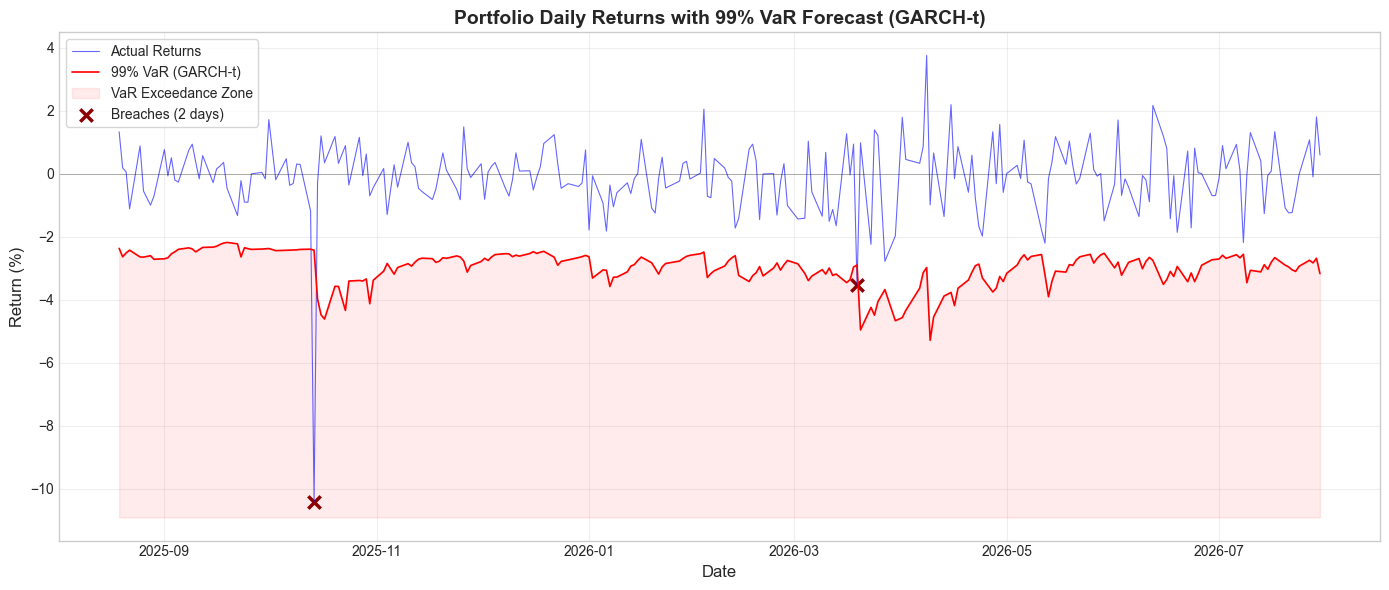

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df['actual'], label='Actual Returns', color='blue', alpha=0.6, linewidth=0.8)
ax.plot(df.index, df['var_99'], label='99% VaR (GARCH-t)', color='red', linewidth=1.2)
ax.fill_between(df.index, df['var_99'], df['actual'].min() - 0.5, color='red', alpha=0.08, label='VaR Exceedance Zone')
if exceptions.sum() > 0:
    ax.scatter(df.index[exceptions], df['actual'][exceptions], 
               color='darkred', marker='x', s=80, linewidth=2.5, 
               label=f'Breaches ({exceptions.sum()} days)')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.4, alpha=0.5)
ax.set_title('Portfolio Daily Returns with 99% VaR Forecast (GARCH-t)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Return (%)', fontsize=12)
ax.legend(loc='upper left', frameon=True, fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dashboard_returns_var.png', dpi=300, bbox_inches='tight')
plt.show()

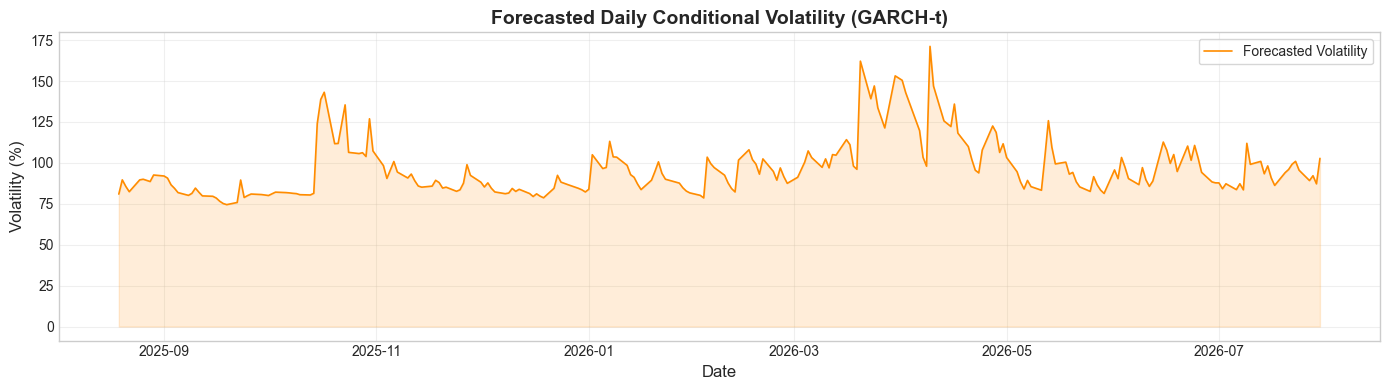

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df['sigma'] * 100, color='darkorange', linewidth=1.2, label='Forecasted Volatility')
ax.set_title('Forecasted Daily Conditional Volatility (GARCH-t)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Volatility (%)', fontsize=12)
ax.fill_between(df.index, 0, df['sigma'] * 100, alpha=0.15, color='darkorange')
ax.legend(loc='upper right', frameon=True)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dashboard_volatility.png', dpi=300, bbox_inches='tight')
plt.show()

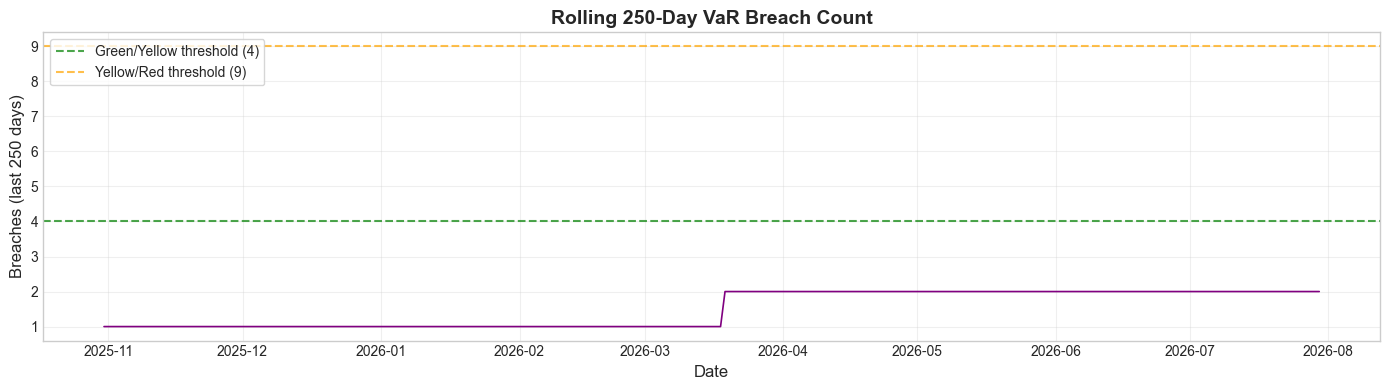

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))
if len(df) >= 100:
    rolling_breaches = []
    for i in range(50, len(df)):
        window = df.iloc[max(0, i-249):i+1]
        rolling_breaches.append((window['actual'] < window['var_99']).sum())
    rolling_idx = df.index[50:]
    ax.plot(rolling_idx, rolling_breaches, color='purple', linewidth=1.2)
    ax.axhline(y=4, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='Green/Yellow threshold (4)')
    ax.axhline(y=9, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label='Yellow/Red threshold (9)')
    ax.set_title('Rolling 250-Day VaR Breach Count', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Breaches (last 250 days)', fontsize=12)
    ax.legend(loc='upper left', frameon=True)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('dashboard_rolling_breaches.png', dpi=300, bbox_inches='tight')
    plt.show()

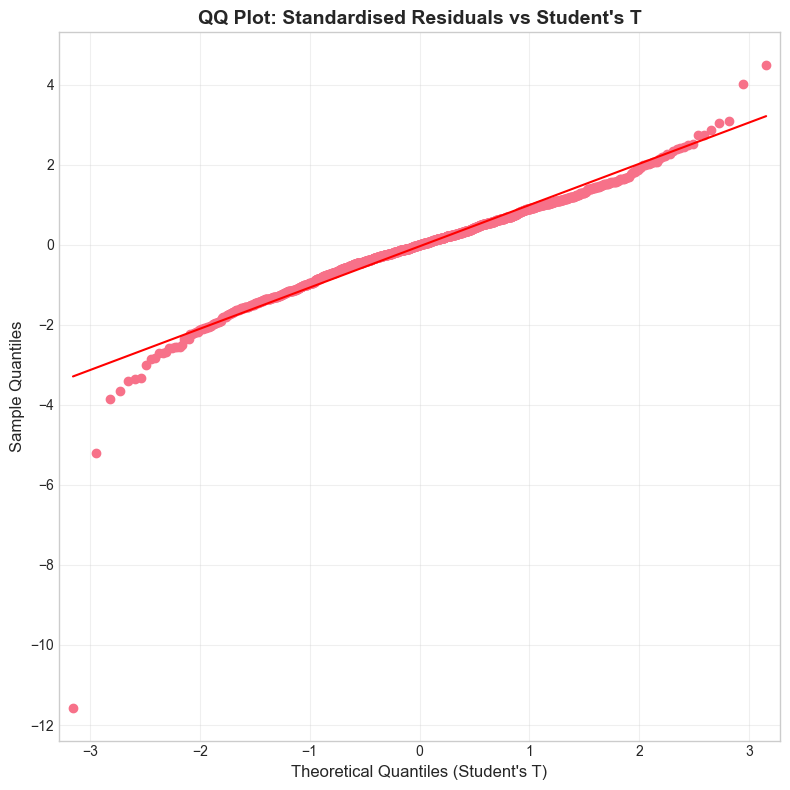

In [ ]:
full_model = arch_model(ret, mean='Constant', p=1, q=1, dist='StudentsT')
full_fit = full_model.fit(disp='off')
std_resid = full_fit.std_resid

fig, ax = plt.subplots(figsize=(8, 8))
qqplot(std_resid, line='s', ax=ax)
ax.set_title('QQ Plot: Standardised Residuals vs Student\'s T', fontsize=14, fontweight='bold')
ax.set_xlabel('Theoretical Quantiles (Student\'s T)', fontsize=12)
ax.set_ylabel('Sample Quantiles', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dashboard_qqplot.png', dpi=300, bbox_inches='tight')
plt.show()

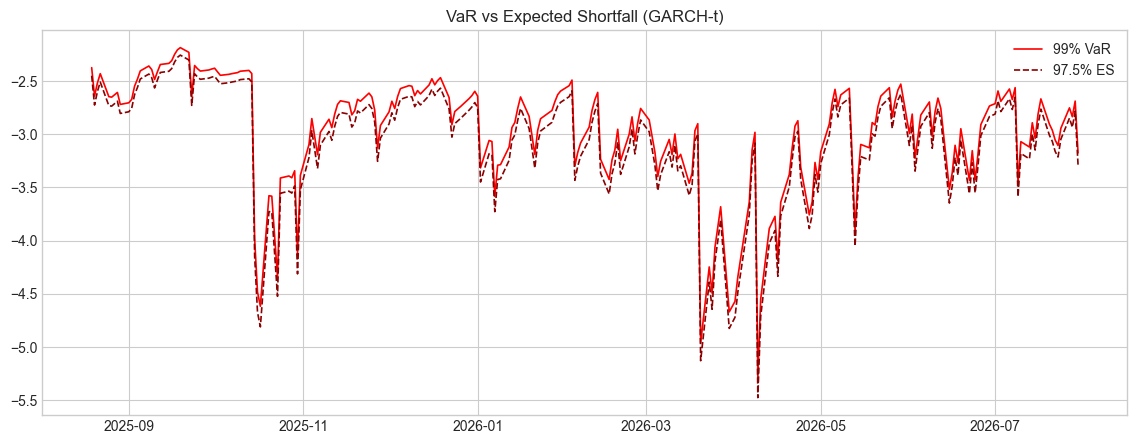

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['var_99'], label='99% VaR', color='red', linewidth=1.2)
ax.plot(df.index, df['es_975'], label='97.5% ES', color='darkred', linewidth=1.2, linestyle='--')
ax.set_title('VaR vs Expected Shortfall (GARCH-t)')
ax.legend()
plt.show()

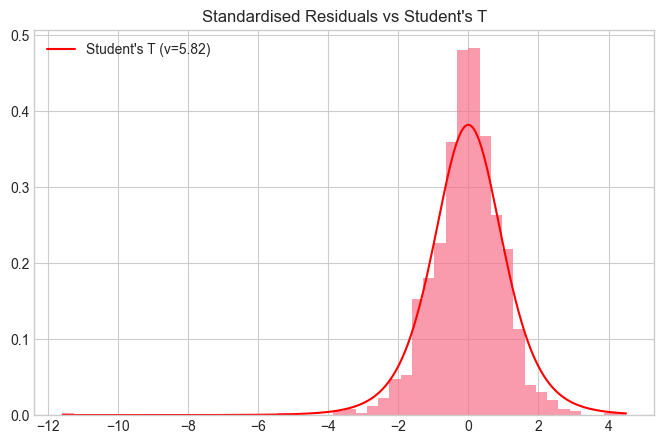

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
std_resid.hist(bins=50, density=True, alpha=0.7)
x = np.linspace(std_resid.min(), std_resid.max(), 200)
ax.plot(x, t.pdf(x, nu), 'r-', label=f'Student\'s T (ν={nu:.2f})')
ax.set_title('Standardised Residuals vs Student\'s T')
ax.legend()
plt.show()

In [ ]:
print(f"{'Date':<12} {'Actual':<10} {'VaR':<10} {'Gap':<10}")
for date in df[exceptions].index:
    actual = df.loc[date, 'actual']
    var = df.loc[date, 'var_99']
    print(f"{date.strftime('%Y-%m-%d'):<12} {actual:<10.2f} {var:<10.2f} {actual-var:<10.2f}")

Date         Actual     VaR        Gap       
2025-10-14   -10.42     -2.43      -7.99     
2026-03-19   -3.55      -2.90      -0.65     


In [ ]:
returns = pd.read_csv('stock_returns.csv', index_col=0, parse_dates=True)
last_window = returns.iloc[-1000:]
weights = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
stocks = ['RELIANCE', 'INFY', 'HDFCBANK', 'ITC', 'TATAMOTORS']
cov_matrix = last_window.cov() * 10000

portfolio_variance = np.dot(weights.T, np.dot(cov_matrix, weights))
portfolio_volatility = np.sqrt(portfolio_variance)

nu = 5.82
z_alpha = t.ppf(0.01, nu)

In [ ]:
mvar = z_alpha * (np.dot(cov_matrix, weights) / portfolio_volatility)

cvar = weights * mvar
total_var_decomp = cvar.sum()

decomp_results = pd.DataFrame({
    'Stock': stocks,
    'Weight (%)': weights * 100,
    'Marginal VaR': mvar,
    'Component VaR': cvar,
    'VaR Contribution (%)': (cvar / total_var_decomp) * 100
}).sort_values('VaR Contribution (%)', ascending=False)

In [ ]:
print(f"Total Portfolio 99% VaR: {total_var_decomp:.4f}%")
print("By Stock:")
print(decomp_results.to_string(index=False))

Total Portfolio 99% VaR: -3.0739%
By Stock:
     Stock  Weight (%)  Marginal VaR  Component VaR  VaR Contribution (%)
TATAMOTORS        20.0     -5.599539      -1.119908             36.433079
      INFY        20.0     -2.861732      -0.572346             18.619696
       ITC        20.0     -2.713712      -0.542742             17.656614
  RELIANCE        20.0     -2.348303      -0.469661             15.279099
  HDFCBANK        20.0     -1.846095      -0.369219             12.011511


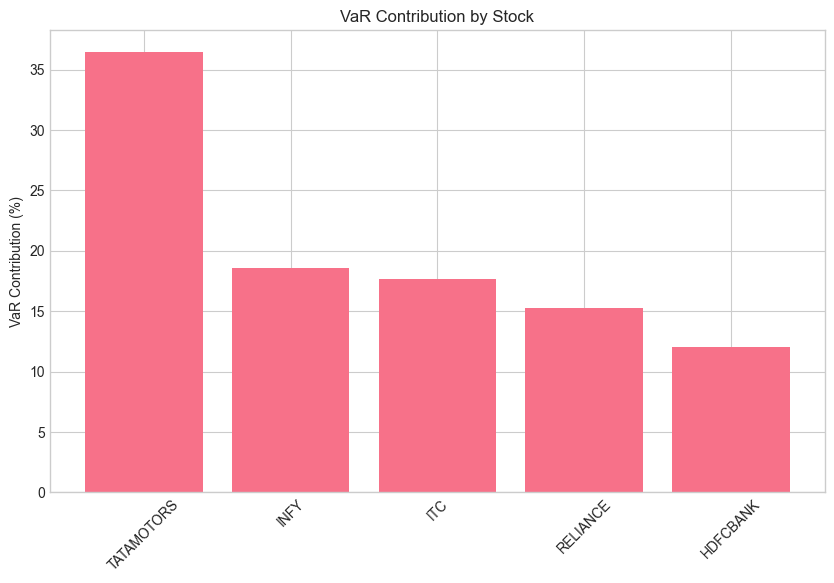

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(decomp_results['Stock'], decomp_results['VaR Contribution (%)'])
ax.set_title('VaR Contribution by Stock')
ax.set_ylabel('VaR Contribution (%)')
plt.xticks(rotation=45)
plt.show()

In [ ]:
covid_shocks = np.array([-0.38, -0.3554, -0.2658, -0.4209, -0.6108])
stocks = ['RELIANCE', 'INFY', 'HDFCBANK', 'ITC', 'TATAMOTORS']

portfolio_shock = -0.4066

current_value = 100

stress_loss = portfolio_shock * current_value
stress_value = current_value + stress_loss

print("Stock-level cumulative shocks:")
for i, stock in enumerate(stocks):
    print(f"{stock}: {covid_shocks[i]*100:.2f}%")

print(f"Portfolio shock: {portfolio_shock*100:.2f}%")
print(f"Current Portfolio Value: ₹{current_value:,.0f} Cr")
print(f"Stress Test Loss: ₹{abs(stress_loss):.2f} Cr")
print(f"Post-Stress Portfolio Value: ₹{stress_value:,.2f} Cr")
print(f"Worst Single Stock Shock: {covid_shocks.min()*100:.2f}% ({stocks[np.argmin(covid_shocks)]})")

Stock-level cumulative shocks:
RELIANCE: -38.00%
INFY: -35.54%
HDFCBANK: -26.58%
ITC: -42.09%
TATAMOTORS: -61.08%
Portfolio shock: -40.66%
Current Portfolio Value: ₹100 Cr
Stress Test Loss: ₹40.66 Cr
Post-Stress Portfolio Value: ₹59.34 Cr
Worst Single Stock Shock: -61.08% (TATAMOTORS)


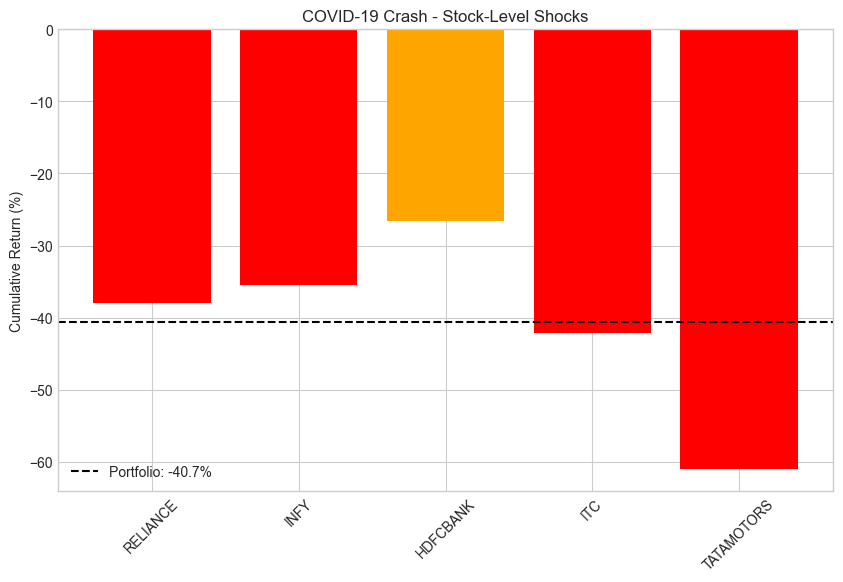

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['red' if x < -0.3 else 'orange' for x in covid_shocks]
ax.bar(stocks, covid_shocks * 100, color=colors)
ax.axhline(y=portfolio_shock * 100, color='black', linestyle='--', label=f'Portfolio: {portfolio_shock*100:.1f}%')
ax.set_title('COVID-19 Crash - Stock-Level Shocks')
ax.set_ylabel('Cumulative Return (%)')
ax.legend()
plt.xticks(rotation=45)
plt.show()

In [ ]:
port_returns = pd.read_csv('portfolio_returns.csv', index_col=0, parse_dates=True).squeeze() * 100

df = pd.read_csv('rolling_forecasts.csv', index_col=0, parse_dates=True)
garch_var = df['var_99']

def historical_var(returns, window, alpha=0.01):
    hs_var = []
    for i in range(window, len(returns)):
        window_returns = returns.iloc[i-window:i]
        hs_var.append(np.percentile(window_returns, alpha * 100))
    return pd.Series(hs_var, index=returns.index[window:])

window = 1000
hs_var_series = historical_var(port_returns, window, alpha=0.01)

hs_var_aligned = hs_var_series.loc[df.index]

mae_garch = np.mean(np.abs(port_returns.loc[df.index] - garch_var))
mae_hs = np.mean(np.abs(port_returns.loc[df.index] - hs_var_aligned))

garch_breaches = (port_returns.loc[df.index] < garch_var).sum()
hs_breaches = (port_returns.loc[df.index] < hs_var_aligned).sum()

print(f"Comparison Period: {df.index[0].strftime('%Y-%m-%d')} to {df.index[-1].strftime('%Y-%m-%d')}")
print(f"Mean Absolute Error (lower is better):")
print(f"GARCH VaR: {mae_garch:.4f}")
print(f"HS VaR:    {mae_hs:.4f}")
print(f"Improvement: {(mae_hs - mae_garch)/mae_hs*100:.1f}%")
print(f"Breach Count (expected: {len(df)*0.01:.1f}):")
print(f"GARCH: {garch_breaches} breaches ({garch_breaches/len(df)*100:.2f}%)")
print(f"HS:    {hs_breaches} breaches ({hs_breaches/len(df)*100:.2f}%)")

Comparison Period: 2025-08-19 to 2026-07-30
Mean Absolute Error (lower is better):
GARCH VaR: 2.9219
HS VaR:    2.5408
Improvement: -15.0%
Breach Count (expected: 2.4):
GARCH: 2 breaches (0.84%)
HS:    3 breaches (1.27%)


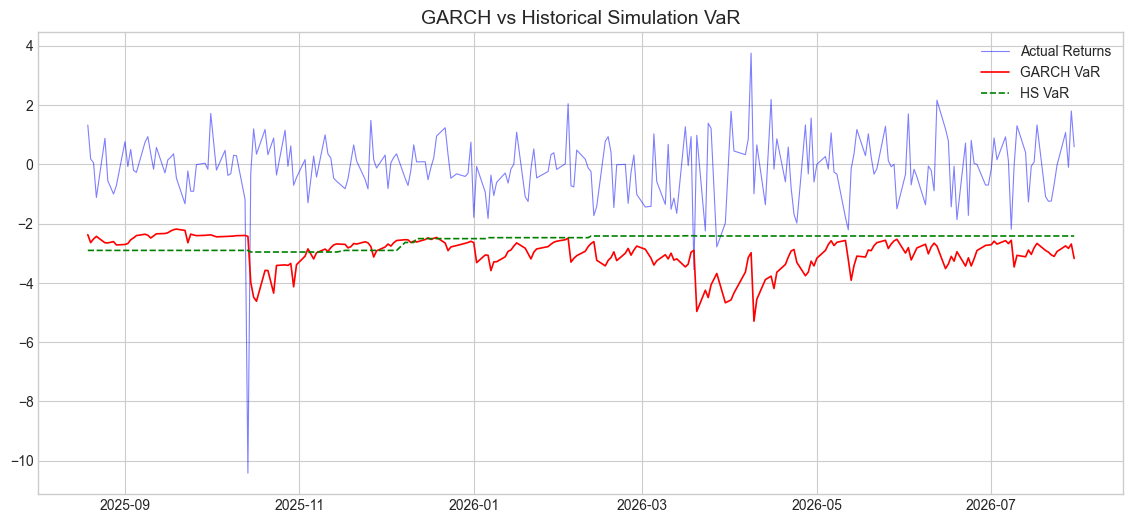

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, port_returns.loc[df.index], label='Actual Returns', alpha=0.5, color='blue', linewidth=0.8)
ax.plot(df.index, garch_var, label='GARCH VaR', color='red', linewidth=1.2)
ax.plot(df.index, hs_var_aligned, label='HS VaR', color='green', linewidth=1.2, linestyle='--')
ax.set_title('GARCH vs Historical Simulation VaR', fontsize=14)
ax.legend()
plt.show()